In [ ]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/parachorpy

from Interfacethermopy import parachor as IFT
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker
# from ctREFPROP.ctREFPROP import REFPROPFunctionLibrary

In [2]:
if __name__ == '__main__':
    
    json_files = ["Mulero_2012.json"]
    model = IFT.InterfacialTension(json_files)
    
    model.ctREFPROP_init('~/Software/REFPROP/REFPROP-cmake/build', gerg_enable=1)
    
    MIXTURE  = "CO2;Methane"
    z        = [0.95, 0.05]
    tol_frac = 5e-6
    kij      = 0.0
    phi_ij   = 1.0
    rows     = []

    comps = [c.strip() for c in MIXTURE.split(';') if c.strip()]
    ncomp = len(comps)

    if len(z) != ncomp:
        raise ValueError(
            f"Composition length mismatch: mixture has {ncomp} components, but z has length {len(z)}."
        )

    # --- Get mixture critical point once ---
    crit_result = model.TP_DIAGRAM(MIXTURE, z, 200.0, verbose=False)
    Tc = crit_result['Tc']
    Pc = crit_result['Pc']

    print("Mixture critical point:")
    print(f"  Tc = {Tc:.6f} K")
    print(f"  Pc = {Pc:.6f} bar")

    # --- Only use temperatures below Tc ---
    T_list      = np.arange(200, int(np.floor(Tc)), 1).tolist()
    N_points    = 20  # Number of points between bubble and dew for gamma_PT calculations

    # --------- MAIN LOOP OVER TEMPERATURES ---------#
    for T in T_list:
        
        result = model.TP_DIAGRAM(MIXTURE, z, T, verbose=False)
        P_bub = result['bubble']['P_bar']
        P_dew = result['dew']['P_bar']
        
        if np.isnan(P_bub) or np.isnan(P_dew):
            print(f"Skipping T = {T:.1f} K because one saturation branch is unavailable.")
            continue
        
        Tc      = result['Tc']
        Pc      = result['Pc']
        Tc_loc  = result['Tc']
        Pc_loc  = result['Pc']
        
        # This is to compute gamma at the saturation (bubble and dew) points
        # PRESSURES = np.array([P_bub * (1.0 - tol_frac),P_dew * (1.0 + tol_frac),])
        
        PRESSURES = np.linspace(P_bub * (1.0 - tol_frac),P_dew * (1.0 + tol_frac),N_points)
        
        Pbar, gamma_Parachor, gamma_WSD, mixcorr_WSD, x, y, rhol, rhov, mml, mmv = \
            model.gamma_PT(MIXTURE, z, T, PRESSURES, kij, phi_ij, correction=True)

        for P, s1, s2, s3, xl, yv, ml, mv, rhol_i, rhog_i in zip(
            Pbar, gamma_Parachor, gamma_WSD, mixcorr_WSD,
            x, y, mml, mmv, rhol, rhov
        ):
            point_type = "bubble" if abs(P - P_bub) <= abs(P - P_dew) else "dew"

            row = {
                "mixture": MIXTURE,
                "T_K": round(T, 4),
                "Tc_K": round(Tc, 6),
                "Pc_bar": round(Pc, 6),
                "kij": kij,
                "phi_ij": phi_ij,
                "point_type": point_type,
                "P_bar": round(P, 6),
                "P_bub_bar": round(P_bub, 6),
                "P_dew_bar": round(P_dew, 6),
                "gamma_Parachor_mN_m": round(s1, 8),
                "gamma_WSD_mN_m": round(s2, 8),
                "mixcorr_WSD": round(s3, 8),
                "M_liq_g_per_mol": round(ml, 8),
                "M_vap_g_per_mol": round(mv, 8),
                "rho_liq_kg_per_m3": round(rhol_i, 6),
                "rho_vap_kg_per_m3": round(rhog_i, 6),
            }

            # overall composition z
            for comp, zi in zip(comps, z):
                row[f"z_{comp}"] = round(float(zi), 6)

            # liquid composition x
            for comp, xi in zip(comps, xl):
                row[f"x_{comp}"] = round(float(xi), 6)

            # vapor composition y
            for comp, yi in zip(comps, yv):
                row[f"y_{comp}"] = round(float(yi), 6)

            rows.append(row)
        
        print(f"\n--- T = {T:.1f} K | Tc = {Tc:.4f} K | Pc = {Pc:.4f} bar ---")
        print(f"  P_bub = {P_bub:.6f} bar  |  P_dew = {P_dew:.6f} bar")
        print(f"  gamma_Parachor : {[round(float(v), 6) for v in gamma_Parachor]}")
        print(f"  gamma_WSD      : {[round(float(v), 6) for v in gamma_WSD]}")
        print(f"  mixcorr_WSD    : {[round(float(v), 6) for v in mixcorr_WSD]}")
        
    # --- Build DataFrame ---
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))
    
    # --- Save CSV ---
    csv_path = "IFT_results.csv"
    df.to_csv(csv_path, index=False)
    print(f"\nSaved {len(df)} rows --> {csv_path}")
    
    # --- Sub-DataFrames for bubble and dew points ---
    df_bub = df[df["point_type"] == "bubble"].reset_index(drop=True)
    df_dew = df[df["point_type"] == "dew"].reset_index(drop=True)

REFPROP version = 10.0
GERG-2008 model = Enabled
Mixture critical point:
  Tc = 300.705989 K
  Pc = 77.909632 bar
Given temperature is less than or equal to max(TMIN, TTRP) for CO2
Computing interfacial tension at T = 1.1*max(TMIN, TTRP) for Parachor method for mixtures
Parachor number calculated: 77.784598 [kg/m3]n ·mN/m
Given temperature is greater than Tc (190.564) for Methane
Computing interfacial tension at T = 0.9*190.564 for Parachor method
Parachor number calculated: 75.160375 [kg/m3]n ·mN/m

--- T = 200.0 K | Tc = 300.7060 K | Pc = 77.9096 bar ---
  P_bub = 15.141576 bar  |  P_dew = 2.475743 bar
  gamma_Parachor : [16.479584, 16.682667, 16.884399, 17.084829, 17.284002, 17.48196, 17.678744, 17.874392, 18.06894, 18.262422, 18.454869, 18.646312, 18.83678, 19.0263, 19.214895, 19.402591, 19.58941, 19.775375, 19.960514, 20.144896]
  gamma_WSD      : [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  mixcorr_WSD    : [0.95, 0.952998

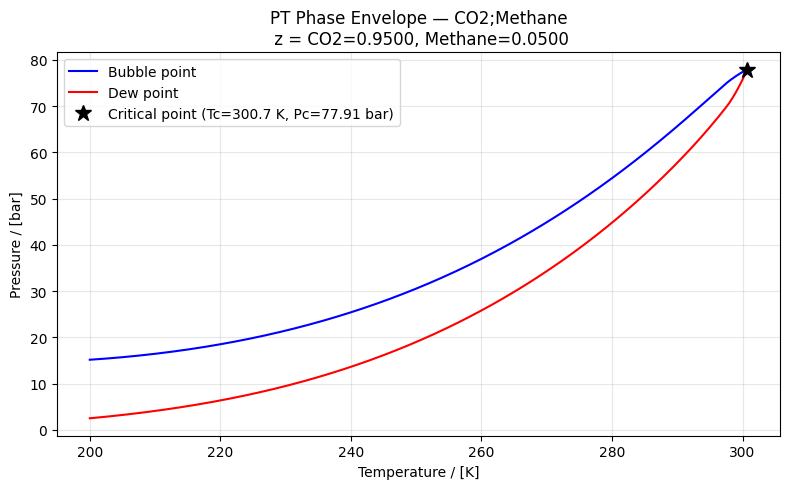

In [3]:
env = model.PT_envelope_curves("IFT_results.csv", n_smooth=400)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(env["T_bub_smooth"], env["P_bub_smooth"], color="b", label="Bubble point")
ax.plot(env["T_dew_smooth"], env["P_dew_smooth"], color="r", label="Dew point")
ax.plot(env["Tc"], env["Pc"], "k*", ms=12,
        label=f"Critical point (Tc={env['Tc']:.1f} K, Pc={env['Pc']:.2f} bar)")

# Optional raw points
# ax.plot(env["T_bub_raw"], env["P_bub_raw"], "bo", ms=3, alpha=0.4)
# ax.plot(env["T_dew_raw"], env["P_dew_raw"], "ro", ms=3, alpha=0.4)

ax.set_xlabel("Temperature / [K]")
ax.set_ylabel("Pressure / [bar]")
ax.set_title(f"PT Phase Envelope — {env['mixture']}\n z = {env['z_label']}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

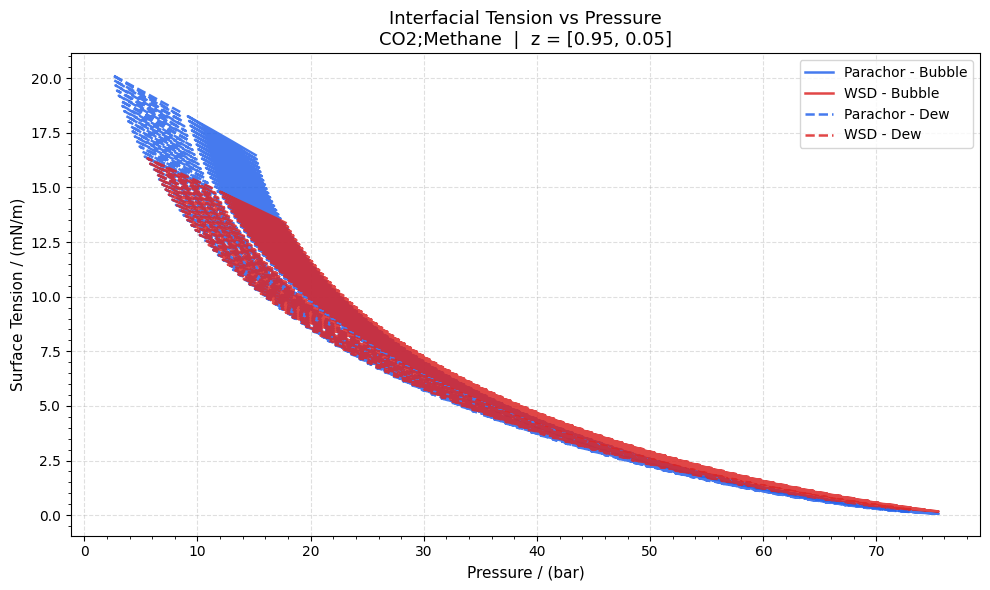

In [4]:

df = pd.read_csv("IFT_results.csv")

# Filter each model independently — keeps rows where that model has a valid value
df_bub_parachor = df_bub[df_bub["gamma_Parachor_mN_m"] >= 1e-4].reset_index(drop=True)
df_bub_wsd      = df_bub[df_bub["gamma_WSD_mN_m"]      >= 1e-4].reset_index(drop=True)
df_dew_parachor = df_dew[df_dew["gamma_Parachor_mN_m"] >= 1e-4].reset_index(drop=True)
df_dew_wsd      = df_dew[df_dew["gamma_WSD_mN_m"]      >= 1e-4].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))

plot_config = [
    (df_bub_parachor, "gamma_Parachor_mN_m", "Parachor - Bubble", "#2563EB", "-",  "None"),
    (df_bub_wsd,      "gamma_WSD_mN_m",      "WSD - Bubble",      "#DC2626", "-",  "None"),
    (df_dew_parachor, "gamma_Parachor_mN_m", "Parachor - Dew",    "#2563EB", "--", "None"),
    (df_dew_wsd,      "gamma_WSD_mN_m",      "WSD - Dew",         "#DC2626", "--", "None"),
]

for df_plot, col, label, color, ls, marker in plot_config:
    ax.plot(df_plot["P_bar"], df_plot[col],
            linestyle=ls, marker=marker, markersize=3,
            linewidth=1.8, color=color, label=label, alpha=0.85)

ax.set_title(f"Interfacial Tension vs Pressure\n{MIXTURE}  |  z = {z}",
             fontsize=13)
ax.set_xlabel("Pressure / (bar)", fontsize=11)
ax.set_ylabel("Surface Tension / (mN/m)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("IFT_vs_Pressure.png", dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# DEBUG for the critical point and saturation spline setup in REFPROP

# import ctREFPROP.ctREFPROP as ct

# MIXTURE = "CO2;Methane"
# z = [0.95, 0.05]

# RP = ct.REFPROPFunctionLibrary('/home/darshan/Software/REFPROP/REFPROP-cmake/build')
# RP.SETPATHdll('/home/darshan/Software/REFPROP/REFPROP-cmake/build')

# iUnits = RP.GETENUMdll(0, "MOLE BASE SI").iEnum

# # If you want GERG, set it before doing the spline/critical calculation
# RP.FLAGSdll("GERG", 1)

# # Set up saturation splines for this composition
# # In REFPROPdll, hIn='SATSPLN' triggers the SATSPLN routine
# sat = RP.REFPROPdll(MIXTURE, "SATSPLN", "", iUnits, 0, 0, 0, 0, z)
# print("SATSPLN:", sat.ierr, sat.herr)

# # Now query the mixture critical point
# res = RP.REFPROPdll(MIXTURE, "", "TC;PC;DC", iUnits, 0, 0, 0, 0, z)
# print("TC [K]   =", res.Output[0])
# print("PC [kPa] =", res.Output[1], " -> ", res.Output[1]/100.0, "bar")
# print("DC       =", res.Output[2])
# print("query:", res.ierr, res.herr)

In [6]:
# import ctREFPROP.ctREFPROP as ct

# RP = ct.REFPROPFunctionLibrary('/home/darshan/Software/REFPROP/REFPROP-cmake/build')
# RP.SETPATHdll('/home/darshan/Software/REFPROP/REFPROP-cmake/build')

# MOLE_BASE_SI = RP.GETENUMdll(0, "MOLE BASE SI").iEnum

# fluid = "CO2"
# z_pure = [1.0]

# res = RP.REFPROPdll(fluid, "", "TMIN;TC", MOLE_BASE_SI, 0, 0, 0, 0, z_pure)

# print("ierr =", res.ierr)
# print("herr =", res.herr.strip())
# print(f"{fluid} Tmin = {res.Output[0]:.6f} K")
# print(f"{fluid} Tc   = {res.Output[1]:.6f} K")